<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.median(numeric_only=True), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2457 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [2]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # TODO: Calculate the linear output (w * x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # TODO: If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:

                    self.w = self.w + self.lr * y[i] * X[i]
                    self.b = self.b + self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [3]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # TODO: 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b
            # TODO: 2. Calculate gradients:
            dw = (1 / n) * np.dot(X.T, (z - y))
            db = (1 / n) * np.sum(z - y)
            # TODO: 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            cost = np.mean((z - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)
model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [4]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # TODO: Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                condition = y[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)
model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

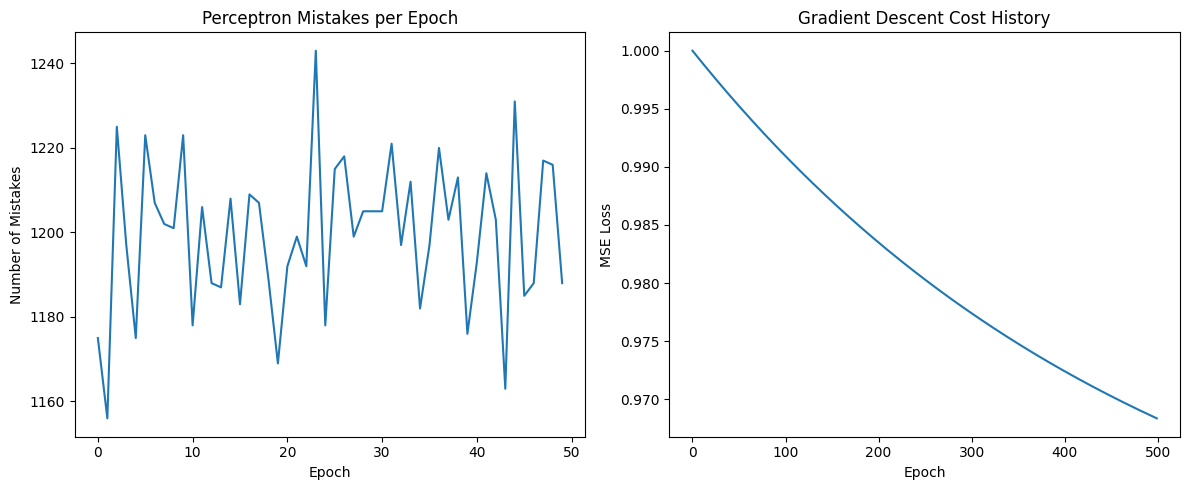

In [5]:
#1

# Convergence Comparison

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(model_p.mistakes)
plt.title("Perceptron Mistakes per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")
plt.subplot(1,2,2)
plt.plot(model_gd.cost_history)
plt.title("Gradient Descent Cost History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()

The Perceptron updates only when it makes mistakes, causing abrupt changes in the learning process. As a result, the mistakes curve can fluctuate significantly from one epoch to another. In contrast, Gradient Descent updates its parameters using information from the entire dataset and follows the direction of the average gradient. This produces a smoother and more gradual reduction in loss over time.

In [6]:
#2
# Accuracy Comparison

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100
pred_p = model_p.predict(X_test)
pred_gd = model_gd.predict(X_test)
pred_margin = model_margin.predict(X_test)
acc_p = accuracy(y_test, pred_p)
acc_gd = accuracy(y_test, pred_gd)
acc_margin = accuracy(y_test, pred_margin)
print("Perceptron Accuracy      : {:.2f}%".format(acc_p))
print("Gradient Descent Accuracy: {:.2f}%".format(acc_gd))
print("Margin Classifier Accuracy: {:.2f}%".format(acc_margin))

Perceptron Accuracy      : 50.79%
Gradient Descent Accuracy: 60.93%
Margin Classifier Accuracy: 60.93%


The model with the highest accuracy performs best on the test dataset. However, accuracy alone does not always reflect confidence or robustness near the decision boundary.

In [8]:
#3
print("Safety Margin Analysis")
print("The Margin Classifier is generally more reliable for samples")
print("that lie close to the decision boundary because it explicitly")
print("maximizes the separation margin between classes.")

Safety Margin Analysis
The Margin Classifier is generally more reliable for samples
that lie close to the decision boundary because it explicitly
maximizes the separation margin between classes.


The Margin Classifier would generally be more trustworthy than the Perceptron for water samples that are very close to the decision boundary. The Perceptron only focuses on achieving correct classifications and does not consider how far a sample is from the boundary. In contrast, the Margin Classifier uses hinge loss and regularization to maximize the separation between classes. This larger safety margin makes the model more robust to small variations, noise, or measurement errors in water quality features, leading to more reliable predictions.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


Q1.

If the learning rate is set too high, the Gradient Descent algorithm may take steps that are too large while updating the weights. Instead of gradually moving toward the minimum of the loss function, it can overshoot the optimal solution repeatedly.
To visualize the idea is with a parabola-shaped loss function.

In this situation:
Small learning rate: The model moves steadily toward the minimum loss and converges.
Moderately large learning rate: The model may oscillate around the minimum before settling.
Very high learning rate: The updates become too large, causing the model to jump back and forth across the minimum.
The loss may increase instead of decrease.
Training can become unstable and eventually diverge, meaning the weights grow very large and never reach an optimal solution.

Q2.

We convert the labels to {-1, 1} because algorithms like the Perceptron and SVM use mathematical formulas that work naturally with positive and negative class labels. This makes the calculations simpler and treats both classes symmetrically.
Using {0,1} would not work well with formulas such as hinge loss because multiplying by 0 removes information about one class.
Therefore, {-1,1} labels simplify the mathematics and are better suited for margin-based classifiers.

Q3.

The Margin Classifier is best suited for handling noisy data. It uses hinge loss and L2 regularization, which help create a larger separation between classes and reduce the impact of outliers.
The Perceptron is less robust because it keeps updating whenever it encounters misclassified points, making it sensitive to noise. Gradient Descent is more stable than the Perceptron, but the Margin Classifier generally provides better generalization on noisy datasets.
Therefore, the Margin Classifier is the most robust choice for noisy and non-separable data.